In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from joblib import dump
from h5py import File
from os.path import exists

import csiborgtools

%matplotlib inline
%load_ext autoreload
%autoreload 2


In [2]:
fpath = "/mnt/extraspace/rstiskalek/catalogs/PV_compilation.hdf5"

with File(fpath, 'r') as f:
    RA_2MTF = f["2MTF/RA"][...]
    DEC_2MTF = f["2MTF/DEC"][...]

fpath = "/mnt/extraspace/rstiskalek/catalogs/PV/CF4/CF4_TFR.hdf5"

with File(fpath, 'r') as f:
    mag  = f["w1"][...]
    eta = f["lgWmxi"][...] - 2.5
    Qw = f["Qw"][...]
    RA = f["RA"][...] * 360 / 24
    DEC = f["DE"][...]
    cz = f["Vcmb"][...]

    # zCMB = f["Vcmb"][...] / 299792.458
    # RA_2MTF = f["2MTF/RA"][...]
    # DEC_2MTF = f["2MTF/DEC"][...]

    m = (mag > 5) & (Qw == 5) & (eta > -0.3)
    mag, eta = mag[m], eta[m]
    RA_CF4, DEC_CF4 = RA[m], DEC[m]
    cz = cz[m]

# RA = f["2MTF/RA"][...]
# DEC = f["2MTF/DEC"][...]

In [90]:
!rm /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/*


reader = csiborgtools.read.Carrick2015Field()
velocity = reader.velocity_field()
boxsize = csiborgtools.simname2boxsize("Carrick2015")

mean_eta, std_eta = 0.0, 0.1

a_TF = -19.85
b_TF = -7
c_TF = -0

h = 1.0
beta = 0.0
kmax = 1
seed = 41

a_TF_dipole_mag = 0.0
a_TF_dipole_l = 150
a_TF_dipole_b = 30

nsamples = 3000

kmax = 1
nrepeat_per_size = 1
zcmb_max = 0.05
# zcmb_max = 0.055001
# nsamples = np.repeat(np.linspace(1000, 20000, kmax, dtype=int), nrepeat_per_size)
nsamples = [1000]
# fname_table = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock_tables/Carrick2MTFmock_table_{zcmb_max}.txt"

# if nsamples is not None and not isinstance(nsamples, int):
#     if exists(fname_table):
#         raise ValueError(f"Table already exists: {fname_table}")

#     np.savetxt(fname_table, nsamples)
#     print(f"Saving the table to `{fname_table}`")

# if isinstance(nsamples, int):
#     nsamples = [nsamples]


for k in trange(kmax * nrepeat_per_size, disable=True):
    gen = np.random.default_rng(seed)
    if nsamples is None:
        # raise RuntimeError("Need to get 2MTF RA/dec.")
        RA = RA_2MTF
        DEC = DEC_2MTF
    else:
        nsamples_current = nsamples[k]
        print(f"Generating {nsamples_current} samples")
        RA = gen.uniform(0, 360, nsamples_current)
        DEC = np.rad2deg(np.arcsin(gen.uniform(-1, 1, nsamples_current)))

    mock, truths = csiborgtools.flow.mock_Carrick2MTF(
        velocity, boxsize, RA, DEC,
        Vext_mag=250, Vext_l=300, Vext_b=-4,
        a_TF_dipole_mag=a_TF_dipole_mag, a_TF_dipole_l=a_TF_dipole_l, a_TF_dipole_b=a_TF_dipole_b,
        mean_eta=mean_eta, std_eta=std_eta,
        m1_selection=11.8,  m2_selection=13.4,
        a_selection=-0.19,
        h=h, a_TF=a_TF, b_TF=b_TF, c_TF=c_TF, sigma_TF=0.3,
        sigma_v=250, beta=beta, Rmax_mask=160,
        mag_min=8, mag_max=17.5,
        seed=seed, verbose=True, return_truths=True,)
    seed += 1
    fname = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed{k}.hdf5"  # noqa
    print("Saving to ", fname)
    with File(fname, 'w') as f:
        for key in mock.keys():
            f.create_dataset(key, data=mock[key])

    fname_truths = fname.replace(".hdf5", "_truths.pkl")
    dump(truths, fname_truths)

/usr/local/shared/python/3.11.7/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Generating 1000 samples
2025-03-12 03:15:07,168 starting rejection sampling.


Rejection sampling: 100%|██████████| 1000/1000 [00:05<00:00, 188.68it/s]


2025-03-12 03:15:12,472 average number of attempts per draw is 215.87.
19 galaxies are above 160 Mpc/h.
Saving to  /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/Carrick2MTFmock_seed0.hdf5


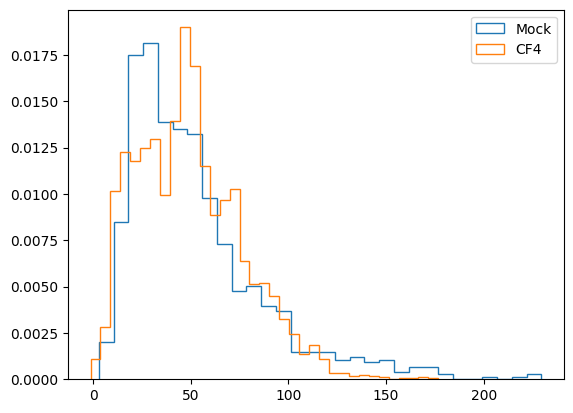

In [91]:
plt.figure()
plt.hist(mock["r"], bins="auto", histtype="step", label="Mock", density=1)
plt.hist(cz / 100, bins="auto", density=1, histtype="step", label="CF4")
plt.legend()
plt.show()

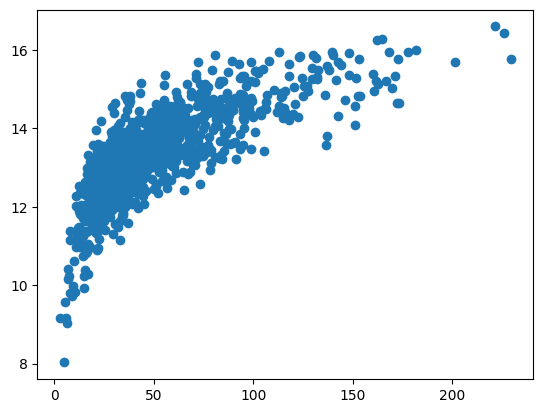

In [87]:
plt.figure()
plt.scatter(mock["r"], mock["mag"])

plt.show()

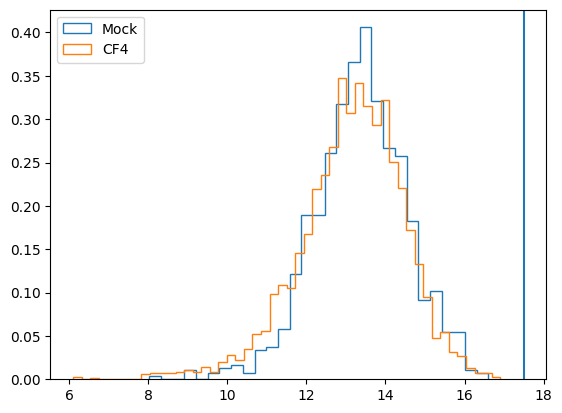

In [88]:
plt.figure()
plt.hist(mock["mag"], bins="auto", histtype="step", density=1, label="Mock")
plt.hist(mag,bins="auto", histtype="step", label="CF4", density=1)
plt.axvline(17.5)
plt.legend()
plt.show()

### Check the magnitude

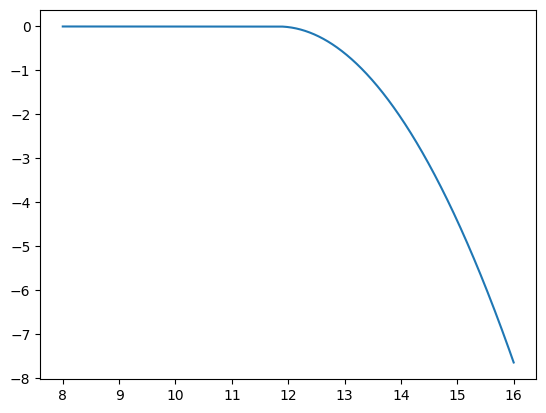

In [84]:
m1 = 11.8
m2 = 13.4
a = -0.19

def log_magnitude_selection(mag, m1, m2, a):
    """
    JAX implementation of `MagnitudeSelection` but natural logarithm,
    whereas the one in `MagnitudeSelection` is base 10.
    """
    return np.log(10) * np.where(
        mag <= m1,
        0,
        a * (mag - m2)**2 - a * (m1 - m2)**2 - 0.6 * (mag - m1))



x = np.linspace(8, 16, 1000)
y = log_magnitude_selection(x, m1, m2, a)


plt.figure()
plt.plot(x, y)
plt.show()
